|<img style="float:left;" src="../images/usherb_transp.gif" width=90% height=90%> |<big>Pierre Proulx, ing, professeur</big>|
|:---|:---|
|Département de génie chimique et de génie biotechnologique |** GCH200-Phénomènes d'échanges I **|


### Problème 18B11

<img src='../images/18B11.png'>


In [1]:
#
# Pierre Proulx
#
# Préparation de l'affichage et des outils de calcul symbolique
#
import sympy as sp
from IPython.display import *
sp.init_printing(use_latex=True)
%matplotlib inline
# Paramètres, variables et fonctions
z,X_A0,X_Ai,X_Bi,D_AB,S,delta_z,c=sp.symbols('z X_A0 X_Ai X_Bi D_AB S delta_z c')  
N_A=sp.Function('N_A')
N_B=sp.Function('N_B')
X_A=sp.Function('X_A')(z)
X_B=sp.Function('X_B')(z)
display(X_Bi)

## a) La solution est pratiquement identique au problème 18B9, avec la différence que l'on travaille avec des fractions molaires au lieu de concentrations, évidemment la loi de Fick est alors $N_A=-cD_{AB} \frac {dX_A}{dz}$

In [2]:
eq=(S*N_A(z)-S*N_A(z+delta_z))/delta_z
eq=sp.limit(eq,delta_z,0).doit()
fick=-c*D_AB*sp.diff(X_A,z) # attention ici la loi de Fick avec des fractions molaires
eq=eq.subs(N_A(z),fick)
X_A_solution_generale=sp.dsolve(eq,X_A)
X_A=X_A_solution_generale.rhs
delta=sp.symbols('delta')
cl1=sp.Eq(X_A.subs(z,0),X_A0)
cl2=sp.Eq(X_A.subs(z,delta),0)
constantes=sp.solve([cl1,cl2],sp.symbols('C1,C2'))
X_A=X_A.subs(constantes)
flux=-c*D_AB*X_A.diff(z)
display(flux)

## b) maintenant il y a une substance B. On recommence pour la substance A en considérant que maintenant la limite ou la fraction molaire est nulle n'est pas $\delta$ mais $\kappa \delta$

In [3]:
kappa=sp.symbols('kappa')
X_Ab=X_A_solution_generale.rhs
cl1=sp.Eq(X_Ab.subs(z,0),X_A0)
cl2=sp.Eq(X_Ab.subs(z,kappa*delta),0)
constantes=sp.solve([cl1,cl2],sp.symbols('C1,C2'))
X_Ab=X_Ab.subs(constantes)
fluxA=-c*D_AB*X_Ab.diff(z)
display(fluxA)

### et on continue en faisant le même bilan pour B, on aura la même solution générale, c-a-dire une droite, donc on peut déjà utiliser la même solution générale

In [4]:
kappa=sp.symbols('kappa')
X_B=X_A_solution_generale.rhs
cl1=sp.Eq(X_B.subs(z,kappa*delta),0)
cl2=sp.Eq(X_B.subs(z,delta),X_Bi)
constantes=sp.solve([cl1,cl2],sp.symbols('C1,C2'))
X_B=X_B.subs(constantes)
D_BA=sp.symbols('D_BA')
fluxB=-c*D_BA*X_B.diff(z)

### les deux flux doivent être égaux et de signes opposés, donc on peut résoudre pour trouver l'inconnue $\kappa$


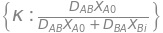

In [5]:
solution_kappa=sp.solve([fluxA+fluxB],kappa)
display(solution_kappa)

In [6]:
display(fluxA.subs(solution_kappa))

### avec ces résultats on pourrait maintenant tracer afin de voir l'effet des 2 coefficients de diffusion. Regardez l'effet sur la position de $\kappa$ des deux coefficients de diffusion. Si B diffuse très vite, alors $\kappa$ sera très près de z=0, sinon si A diffuse beaucoup plus rapidement que B, alors $\kappa$ sera très près de $\delta$

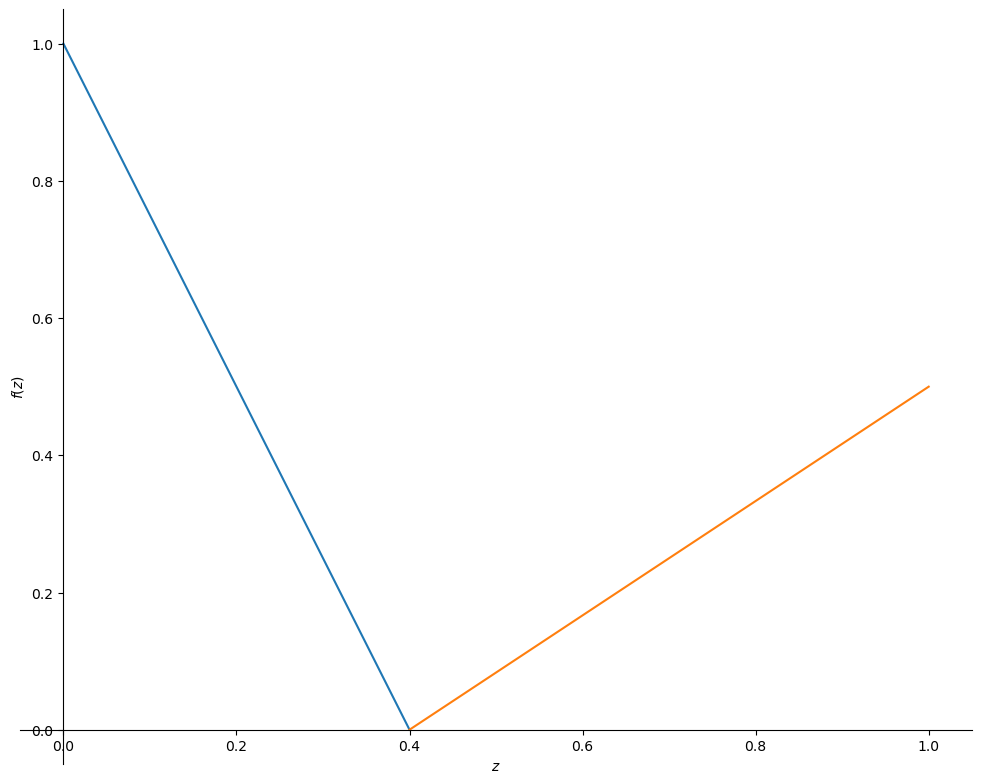

In [7]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=10,8
dico={'D_AB':1.e-9,'D_BA':3.e-9,'X_A0':1,'X_Bi':0.5,'delta':1}
k=solution_kappa[kappa]   # la solution est dans un dictionnaire
k=k.subs(dico)      # on utilise la variable k qui contiendra la valeur numérique de kappa
X_Ab=X_Ab.subs(dico).subs(kappa,k)
X_B=X_B.subs(dico).subs(kappa,k)
sp.plot((X_Ab,(z,0,k)),(X_B,(z,k,1)));